# Predicting Credit Card Payment Default — A Big Data Machine Learning Pipeline

---
**Group Members:**
1. RADS BANDARA — 31834
2. RISKEY MAM — 31839
---



## Environment Setup and Spark Session

In [1]:
import os, json, time, warnings
warnings.filterwarnings("ignore")
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import DoubleType
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier, DecisionTreeClassifier
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

sns.set_theme(style="whitegrid", palette="deep")
PALETTE = ["#1E2761", "#CADCFC", "#F96167", "#97BC62", "#065A82"]


In [2]:
spark = (
    SparkSession.builder
    .appName("CreditCardDefault-BigDataML")
    .master("local[*]")
    .config("spark.driver.memory", "4g")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")
spark


In [3]:
import logging
logging.getLogger("py4j").setLevel(logging.ERROR)


## Data Loading



In [4]:
df = spark.read.csv("../data/default_of_credit_card_clients.csv", header=True, inferSchema=True)
df = df.withColumnRenamed("default payment next month", "DEFAULT")

print("Rows:", df.count(), " Columns:", len(df.columns))
df.printSchema()


Rows: 30000  Columns: 25
root
 |-- ID: integer (nullable = true)
 |-- LIMIT_BAL: integer (nullable = true)
 |-- SEX: integer (nullable = true)
 |-- EDUCATION: integer (nullable = true)
 |-- MARRIAGE: integer (nullable = true)
 |-- AGE: integer (nullable = true)
 |-- PAY_0: integer (nullable = true)
 |-- PAY_2: integer (nullable = true)
 |-- PAY_3: integer (nullable = true)
 |-- PAY_4: integer (nullable = true)
 |-- PAY_5: integer (nullable = true)
 |-- PAY_6: integer (nullable = true)
 |-- BILL_AMT1: integer (nullable = true)
 |-- BILL_AMT2: integer (nullable = true)
 |-- BILL_AMT3: integer (nullable = true)
 |-- BILL_AMT4: integer (nullable = true)
 |-- BILL_AMT5: integer (nullable = true)
 |-- BILL_AMT6: integer (nullable = true)
 |-- PAY_AMT1: integer (nullable = true)
 |-- PAY_AMT2: integer (nullable = true)
 |-- PAY_AMT3: integer (nullable = true)
 |-- PAY_AMT4: integer (nullable = true)
 |-- PAY_AMT5: integer (nullable = true)
 |-- PAY_AMT6: integer (nullable = true)
 |-- DEFAULT

In [5]:
df.show(5)

+---+---------+---+---------+--------+---+-----+-----+-----+-----+-----+-----+---------+---------+---------+---------+---------+---------+--------+--------+--------+--------+--------+--------+-------+
| ID|LIMIT_BAL|SEX|EDUCATION|MARRIAGE|AGE|PAY_0|PAY_2|PAY_3|PAY_4|PAY_5|PAY_6|BILL_AMT1|BILL_AMT2|BILL_AMT3|BILL_AMT4|BILL_AMT5|BILL_AMT6|PAY_AMT1|PAY_AMT2|PAY_AMT3|PAY_AMT4|PAY_AMT5|PAY_AMT6|DEFAULT|
+---+---------+---+---------+--------+---+-----+-----+-----+-----+-----+-----+---------+---------+---------+---------+---------+---------+--------+--------+--------+--------+--------+--------+-------+
|  1|    20000|  2|        2|       1| 24|    2|    2|   -1|   -1|   -2|   -2|     3913|     3102|      689|        0|        0|        0|       0|     689|       0|       0|       0|       0|      1|
|  2|   120000|  2|        2|       2| 26|   -1|    2|    0|    0|    0|    2|     2682|     1725|     2682|     3272|     3455|     3261|       0|    1000|    1000|    1000|       0|    2000|    

## Data Cleaning

We check and handle four classes of data-quality issues :

1. **Duplicate rows**
2. **Missing values**
3. **Undocumented / inconsistent category codes** in `EDUCATION` and `MARRIAGE`
4. **Sanity range checks** on `AGE`


In [6]:
# 1 Duplicates
n_before = df.count()
df = df.dropDuplicates()
n_after = df.count()
print(f"Rows before de-dup: {n_before} | after: {n_after} | duplicates removed: {n_before - n_after}")


Rows before de-dup: 30000 | after: 30000 | duplicates removed: 0


In [7]:
# 2 Missing values (per column)
null_counts = df.select([F.sum(F.col(c).isNull().cast("int")).alias(c) for c in df.columns])
null_counts.show(vertical=True, truncate=False)


-RECORD 0--------
 ID        | 0   
 LIMIT_BAL | 0   
 SEX       | 0   
 EDUCATION | 0   
 MARRIAGE  | 0   
 AGE       | 0   
 PAY_0     | 0   
 PAY_2     | 0   
 PAY_3     | 0   
 PAY_4     | 0   
 PAY_5     | 0   
 PAY_6     | 0   
 BILL_AMT1 | 0   
 BILL_AMT2 | 0   
 BILL_AMT3 | 0   
 BILL_AMT4 | 0   
 BILL_AMT5 | 0   
 BILL_AMT6 | 0   
 PAY_AMT1  | 0   
 PAY_AMT2  | 0   
 PAY_AMT3  | 0   
 PAY_AMT4  | 0   
 PAY_AMT5  | 0   
 PAY_AMT6  | 0   
 DEFAULT   | 0   



In [8]:
# 3 EDUCATION / MARRIAGE: the dataset documentation only defines EDUCATION in {1,2,3,4}
# and MARRIAGE in {1,2,3}, yet the raw data also contains 0, 5, 6 (EDUCATION) and 0 (MARRIAGE).
# These undocumented codes are collapsed into the closest documented "Others" category
# rather than dropped, since they represent a meaningful (if mislabelled) share of clients.
print("EDUCATION value counts BEFORE cleaning:")
df.groupBy("EDUCATION").count().orderBy("EDUCATION").show()
print("MARRIAGE value counts BEFORE cleaning:")
df.groupBy("MARRIAGE").count().orderBy("MARRIAGE").show()


EDUCATION value counts BEFORE cleaning:
+---------+-----+
|EDUCATION|count|
+---------+-----+
|        0|   14|
|        1|10585|
|        2|14030|
|        3| 4917|
|        4|  123|
|        5|  280|
|        6|   51|
+---------+-----+

MARRIAGE value counts BEFORE cleaning:
+--------+-----+
|MARRIAGE|count|
+--------+-----+
|       0|   54|
|       1|13659|
|       2|15964|
|       3|  323|
+--------+-----+



In [9]:
df = df.withColumn(
    "EDUCATION",
    F.when(F.col("EDUCATION").isin([0, 5, 6]), F.lit(4)).otherwise(F.col("EDUCATION"))
)
df = df.withColumn(
    "MARRIAGE",
    F.when(F.col("MARRIAGE") == 0, F.lit(3)).otherwise(F.col("MARRIAGE"))
)

print("EDUCATION value counts AFTER cleaning:")
df.groupBy("EDUCATION").count().orderBy("EDUCATION").show()
print("MARRIAGE value counts AFTER cleaning:")
df.groupBy("MARRIAGE").count().orderBy("MARRIAGE").show()


EDUCATION value counts AFTER cleaning:
+---------+-----+
|EDUCATION|count|
+---------+-----+
|        1|10585|
|        2|14030|
|        3| 4917|
|        4|  468|
+---------+-----+

MARRIAGE value counts AFTER cleaning:
+--------+-----+
|MARRIAGE|count|
+--------+-----+
|       1|13659|
|       2|15964|
|       3|  377|
+--------+-----+



In [10]:
# 4 Sanity range check on AGE, and drop the non-predictive ID column
age_stats = df.select(F.min("AGE").alias("min_age"), F.max("AGE").alias("max_age")).collect()[0]
print("AGE range:", age_stats["min_age"], "-", age_stats["max_age"], "(plausible adult range, no cleaning needed)")

df = df.drop("ID")
print("Final cleaned shape:", df.count(), "rows x", len(df.columns), "columns")


AGE range: 21 - 79 (plausible adult range, no cleaning needed)
Final cleaned shape: 30000 rows x 24 columns


## Exploratory Data Analysis



In [12]:
%matplotlib inline

   DEFAULT  count
0        1   6636
1        0  23364


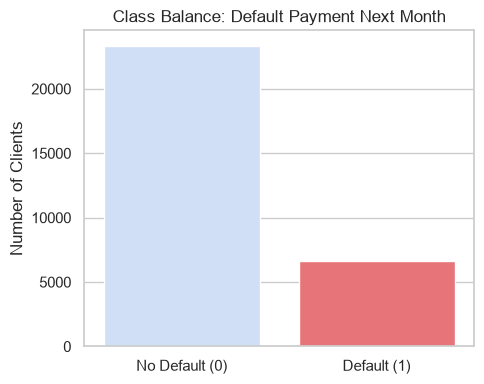

In [14]:
class_balance = df.groupBy("DEFAULT").count().toPandas()
print(class_balance)

plt.figure(figsize=(5,4))
sns.barplot(data=class_balance, x="DEFAULT", y="count", hue="DEFAULT", palette=[PALETTE[1], PALETTE[2]], legend=False)
plt.xticks([0,1], ["No Default (0)", "Default (1)"])
plt.title("Class Balance: Default Payment Next Month")
plt.ylabel("Number of Clients")
plt.xlabel("")
plt.tight_layout()
plt.show()


   SEX  default_rate      n   label
0    1      0.241672  11888    Male
1    2      0.207763  18112  Female


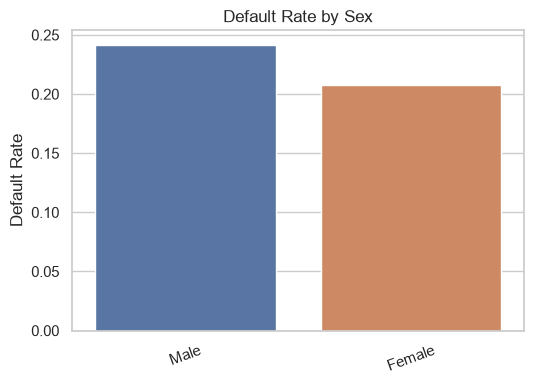

   EDUCATION  default_rate      n        label
0          1      0.192348  10585  Grad School
2          2      0.237349  14030   University
1          3      0.251576   4917  High School
3          4      0.070513    468       Others


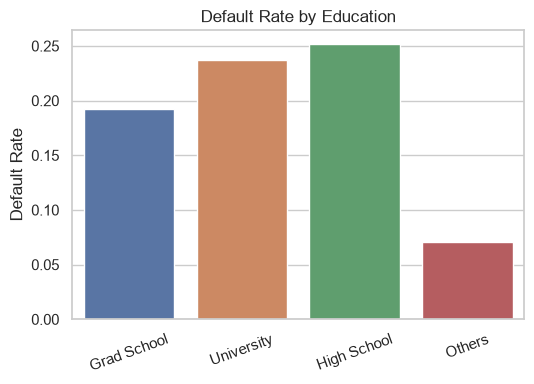

   MARRIAGE  default_rate      n    label
0         1      0.234717  13659  Married
2         2      0.209283  15964   Single
1         3      0.236074    377   Others


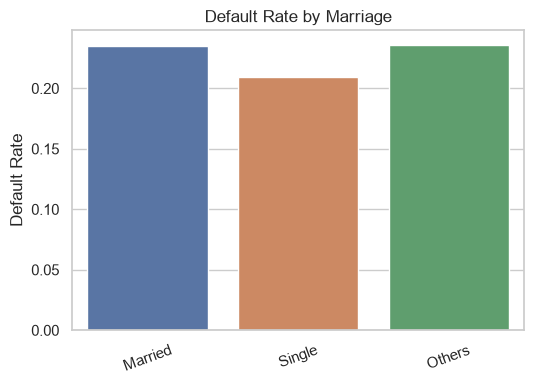

In [21]:
for cat, labels in [
    ("SEX", {1: "Male", 2: "Female"}),
    ("EDUCATION", {1: "Grad School", 2: "University", 3: "High School", 4: "Others"}),
    ("MARRIAGE", {1: "Married", 2: "Single", 3: "Others"}),
]:
    grp = df.groupBy(cat).agg(F.avg("DEFAULT").alias("default_rate"), F.count("*").alias("n")).toPandas()
    grp = grp.sort_values(cat)
    grp["label"] = grp[cat].map(labels)
    print(grp)

    plt.figure(figsize=(5.5,4))
    sns.barplot(data=grp, x="label", y="default_rate", hue="label", legend=False)
    plt.title(f"Default Rate by {cat.title()}")
    plt.ylabel("Default Rate"); plt.xlabel(""); plt.xticks(rotation=20)
    plt.tight_layout(); plt.show()


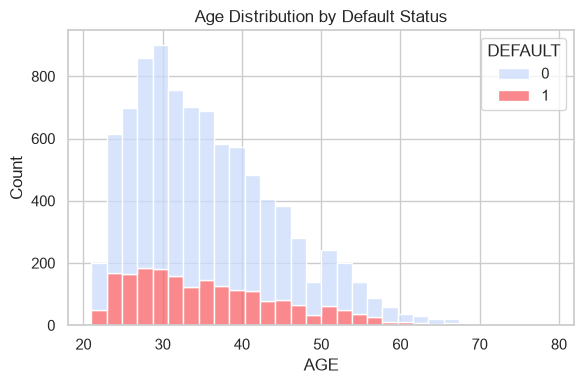

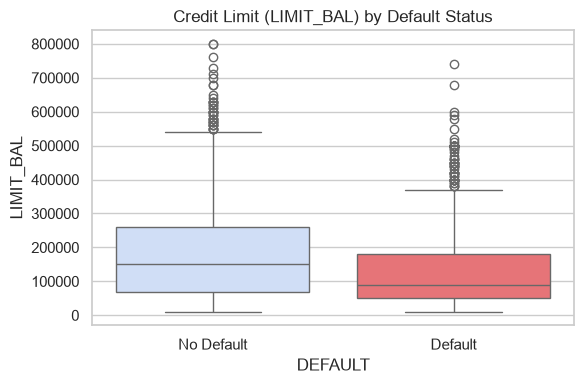

In [15]:
pdf_sample = df.sample(fraction=0.3, seed=42).toPandas()

plt.figure(figsize=(6,4))
sns.histplot(data=pdf_sample, x="AGE", hue="DEFAULT", bins=30, multiple="stack", palette=[PALETTE[1], PALETTE[2]])
plt.title("Age Distribution by Default Status")
plt.tight_layout(); plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(data=pdf_sample, x="DEFAULT", y="LIMIT_BAL", hue="DEFAULT", palette=[PALETTE[1], PALETTE[2]], legend=False)
plt.xticks([0,1], ["No Default", "Default"])
plt.title("Credit Limit (LIMIT_BAL) by Default Status")
plt.tight_layout(); plt.show()


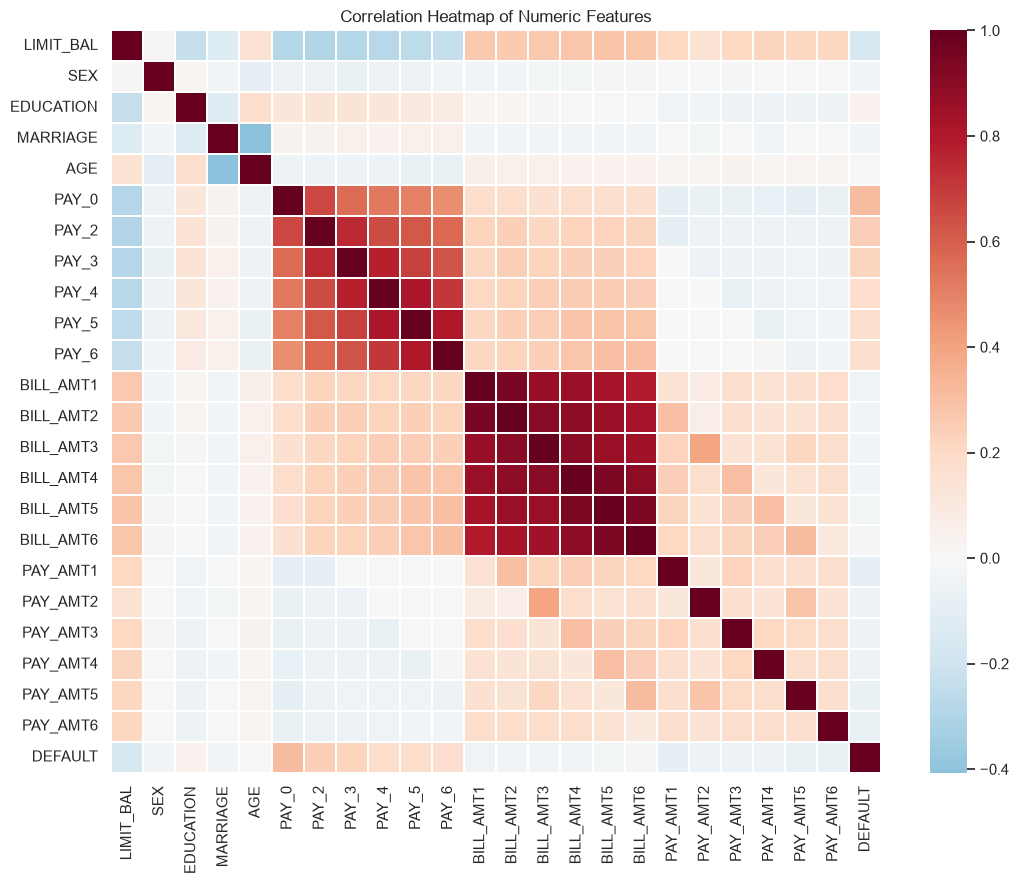

Top features correlated with DEFAULT:
PAY_0        0.309211
PAY_2        0.247760
PAY_3        0.220246
PAY_4        0.184537
PAY_5        0.180803
LIMIT_BAL    0.169890
PAY_6        0.168432
PAY_AMT1     0.083005
Name: DEFAULT, dtype: float64


In [16]:
numeric_cols = [c for c, t in df.dtypes if t in ("int", "double", "bigint")]
corr = pdf_sample[numeric_cols].corr()

plt.figure(figsize=(11,9))
sns.heatmap(corr, cmap="RdBu_r", center=0, linewidths=0.3)
plt.title("Correlation Heatmap of Numeric Features")
plt.tight_layout(); plt.show()

print("Top features correlated with DEFAULT:")
print(corr["DEFAULT"].drop("DEFAULT").abs().sort_values(ascending=False).head(8))


    PAY_0  default_rate      n
6      -2      0.132294   2759
5      -1      0.167781   5686
9       0      0.128113  14737
2       1      0.339479   3688
7       2      0.691414   2667
3       3      0.757764    322
8       4      0.684211     76
1       5      0.500000     26
0       6      0.545455     11
4       7      0.777778      9
10      8      0.578947     19


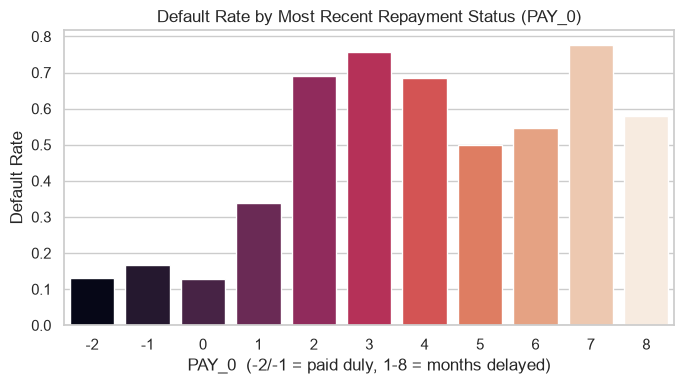

In [17]:
pay0 = df.groupBy("PAY_0").agg(F.avg("DEFAULT").alias("default_rate"), F.count("*").alias("n")).toPandas().sort_values("PAY_0")
print(pay0)

plt.figure(figsize=(7,4))
sns.barplot(data=pay0, x="PAY_0", y="default_rate", hue="PAY_0", palette="rocket", legend=False)
plt.title("Default Rate by Most Recent Repayment Status (PAY_0)")
plt.xlabel("PAY_0  (-2/-1 = paid duly, 1-8 = months delayed)")
plt.ylabel("Default Rate")
plt.tight_layout(); plt.show()


## Feature Engineering

Using **Spark ML transformers**, we build:

- **Derived numeric features** (domain knowledge, computed with Spark DataFrame expressions):
  - `AVG_BILL_AMT`, `AVG_PAY_AMT` — 6-month averages, smoothing out single-month noise.
  - `CREDIT_UTILIZATION` = average bill ÷ credit limit — how heavily the client uses their
    credit line.
  - `PAY_TO_BILL_RATIO` = average payment ÷ average bill — how much of their bill a client
    typically covers.
  - `MONTHS_DELAYED` — count of the 6 months where the repayment status shows a delay
    (`PAY_x > 0`).
- **Categorical encoding:** `StringIndexer` → `OneHotEncoder` for `SEX`, `EDUCATION`,
  `MARRIAGE`.
- **Vector assembly:** `VectorAssembler` combines all numeric + one-hot columns into a single
  `features` vector.
- **Scaling:** `StandardScaler` (zero mean, unit variance) — mainly benefits Logistic
  Regression; harmless for the tree-based models.

All of these steps are wired together into a single **Spark ML `Pipeline`** , so
that preprocessing and modelling are fit/applied consistently and reproducibly.


In [18]:
df = df.withColumn("AVG_BILL_AMT", (F.col("BILL_AMT1")+F.col("BILL_AMT2")+F.col("BILL_AMT3")+
                                        F.col("BILL_AMT4")+F.col("BILL_AMT5")+F.col("BILL_AMT6"))/6.0)
df = df.withColumn("AVG_PAY_AMT", (F.col("PAY_AMT1")+F.col("PAY_AMT2")+F.col("PAY_AMT3")+
                                    F.col("PAY_AMT4")+F.col("PAY_AMT5")+F.col("PAY_AMT6"))/6.0)
df = df.withColumn(
    "CREDIT_UTILIZATION",
    F.when(F.col("LIMIT_BAL") > 0, F.col("AVG_BILL_AMT") / F.col("LIMIT_BAL")).otherwise(0.0)
)
df = df.withColumn(
    "PAY_TO_BILL_RATIO",
    F.when(F.col("AVG_BILL_AMT") > 0, F.col("AVG_PAY_AMT") / F.col("AVG_BILL_AMT")).otherwise(F.lit(0.0))
)
df = df.withColumn(
    "MONTHS_DELAYED",
    sum(F.when(F.col(c) > 0, 1).otherwise(0) for c in ["PAY_0","PAY_2","PAY_3","PAY_4","PAY_5","PAY_6"])
)

df.select("AVG_BILL_AMT","AVG_PAY_AMT","CREDIT_UTILIZATION","PAY_TO_BILL_RATIO","MONTHS_DELAYED").show(5)


+------------------+------------------+--------------------+--------------------+--------------+
|      AVG_BILL_AMT|       AVG_PAY_AMT|  CREDIT_UTILIZATION|   PAY_TO_BILL_RATIO|MONTHS_DELAYED|
+------------------+------------------+--------------------+--------------------+--------------+
|2846.1666666666665| 833.3333333333334|0.023718055555555555|  0.2927914739122797|             2|
|39685.666666666664|1295.3333333333333|  0.7937133333333333|0.032639827981555056|             0|
| 5310.666666666667|2733.3333333333335| 0.05900740740740741|  0.5146874215415516|             0|
| 6701.333333333333|            6594.5| 0.13402666666666666|   0.984057898925587|             0|
|           65476.0|3223.6666666666665|  0.9353714285714285| 0.04923432504530922|             0|
+------------------+------------------+--------------------+--------------------+--------------+
only showing top 5 rows


In [19]:
categorical_cols = ["SEX", "EDUCATION", "MARRIAGE"]
numeric_cols_final = [
    "LIMIT_BAL", "AGE",
    "PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6",
    "BILL_AMT1", "BILL_AMT2", "BILL_AMT3", "BILL_AMT4", "BILL_AMT5", "BILL_AMT6",
    "PAY_AMT1", "PAY_AMT2", "PAY_AMT3", "PAY_AMT4", "PAY_AMT5", "PAY_AMT6",
    "AVG_BILL_AMT", "AVG_PAY_AMT", "CREDIT_UTILIZATION", "PAY_TO_BILL_RATIO", "MONTHS_DELAYED",
]

indexers = [StringIndexer(inputCol=c, outputCol=f"{c}_idx") for c in categorical_cols]
encoders = [OneHotEncoder(inputCol=f"{c}_idx", outputCol=f"{c}_ohe") for c in categorical_cols]
assembler_inputs = numeric_cols_final + [f"{c}_ohe" for c in categorical_cols]
assembler = VectorAssembler(inputCols=assembler_inputs, outputCol="features_raw")
scaler = StandardScaler(inputCol="features_raw", outputCol="features", withMean=True, withStd=True)

df = df.withColumn("label", F.col("DEFAULT").cast(DoubleType()))
print("Total feature columns feeding the assembler:", len(assembler_inputs))


Total feature columns feeding the assembler: 28


## Train/Test Split and the Spark ML Pipeline



In [20]:
train_df, test_df = df.randomSplit([0.8, 0.2], seed=42)
print("Train rows:", train_df.count(), " Test rows:", test_df.count())


Train rows: 24132  Test rows: 5868


In [21]:
lr = LogisticRegression(featuresCol="features", labelCol="label", maxIter=50, regParam=0.01, elasticNetParam=0.0)
rf = RandomForestClassifier(featuresCol="features", labelCol="label", numTrees=150, maxDepth=8, seed=42)
dt = DecisionTreeClassifier(featuresCol="features", labelCol="label", maxDepth=6, seed=42)

model_specs = {"LogisticRegression": lr, "RandomForest": rf, "DecisionTree": dt}

# NOTE: for tree-based models Spark's "rawPrediction" column holds raw class
# counts rather than a calibrated score, which distorts AUC. We evaluate AUC using the
# "probability" column instead, which is well-defined and comparable across all three models.
bin_eval_auc = BinaryClassificationEvaluator(labelCol="label", rawPredictionCol="probability", metricName="areaUnderROC")
bin_eval_pr  = BinaryClassificationEvaluator(labelCol="label", rawPredictionCol="probability", metricName="areaUnderPR")
acc_eval  = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
f1_eval   = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="f1")
prec_eval = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedPrecision")
rec_eval  = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedRecall")

metrics = {}
fitted_models = {}

for name, clf in model_specs.items():
    stages = indexers + encoders + [assembler, scaler, clf]
    pipeline = Pipeline(stages=stages)

    t0 = time.time()
    pmodel = pipeline.fit(train_df)
    fit_time = time.time() - t0

    preds = pmodel.transform(test_df)

    m = {
        "accuracy": acc_eval.evaluate(preds),
        "precision": prec_eval.evaluate(preds),
        "recall": rec_eval.evaluate(preds),
        "f1": f1_eval.evaluate(preds),
        "auc_roc": bin_eval_auc.evaluate(preds),
        "auc_pr": bin_eval_pr.evaluate(preds),
        "fit_time_sec": fit_time,
    }
    metrics[name] = m
    fitted_models[name] = pmodel
    print(f"{name:20s} -> {m}")


LogisticRegression   -> {'accuracy': 0.8069188820722563, 'precision': 0.7841903430023697, 'recall': 0.8069188820722564, 'f1': 0.7745969192495012, 'auc_roc': 0.7502972592208782, 'auc_pr': 0.5115003186969705, 'fit_time_sec': 11.876341104507446}
RandomForest         -> {'accuracy': 0.8169734151329243, 'precision': 0.7985229717862328, 'recall': 0.8169734151329244, 'f1': 0.7966815126792973, 'auc_roc': 0.7799060047886586, 'auc_pr': 0.5541639429394923, 'fit_time_sec': 16.26027774810791}
DecisionTree         -> {'accuracy': 0.8178254942058623, 'precision': 0.7995730580112104, 'recall': 0.8178254942058623, 'f1': 0.7950504253264667, 'auc_roc': 0.7374257063610595, 'auc_pr': 0.5159441807107292, 'fit_time_sec': 3.992280960083008}


## Model Evaluation and Comparison


In [22]:
comp_df = pd.DataFrame(metrics).T[["accuracy","precision","recall","f1","auc_roc","auc_pr","fit_time_sec"]]
comp_df = comp_df.round(4)
comp_df


,accuracy,precision,recall,f1,auc_roc,auc_pr,fit_time_sec
LogisticRegression,0.8069,0.7842,0.8069,0.7746,0.7503,0.5115,11.8763
RandomForest,0.8170,0.7985,0.8170,0.7967,0.7799,0.5542,16.2603
DecisionTree,0.8178,0.7996,0.8178,0.7951,0.7374,0.5159,3.9923


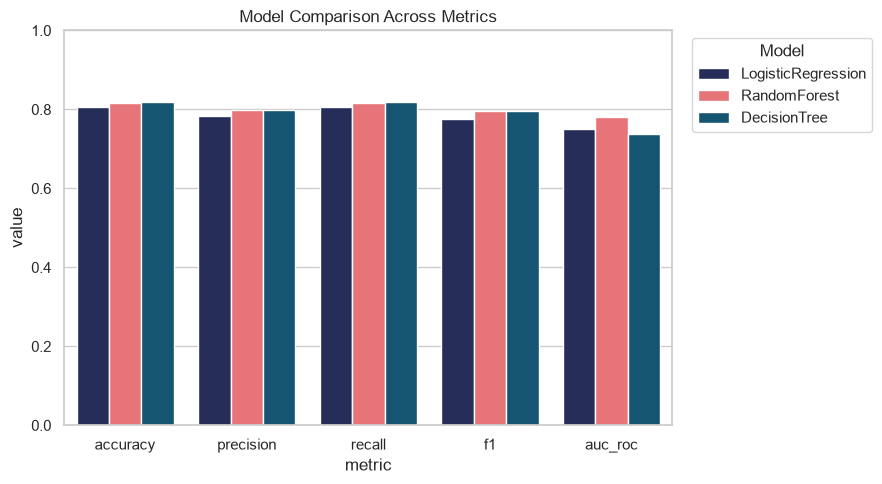

In [23]:
comp_plot = comp_df[["accuracy","precision","recall","f1","auc_roc"]].reset_index().rename(columns={"index":"model"})
comp_melt = comp_plot.melt(id_vars="model", var_name="metric", value_name="value")

plt.figure(figsize=(9,5))
sns.barplot(data=comp_melt, x="metric", y="value", hue="model", palette=[PALETTE[0], PALETTE[2], PALETTE[4]])
plt.title("Model Comparison Across Metrics")
plt.ylim(0,1)
plt.legend(title="Model", bbox_to_anchor=(1.02,1), loc="upper left")
plt.tight_layout(); plt.show()


In [24]:
# Confusion matrices
for name, pmodel in fitted_models.items():
    preds = pmodel.transform(test_df)
    cm = preds.groupBy("label","prediction").count().toPandas()
    print(f"\nConfusion matrix — {name}")
    print(cm.pivot(index="label", columns="prediction", values="count").fillna(0))



Confusion matrix — LogisticRegression
prediction   0.0  1.0
label                
0.0         4387  191
1.0          942  348

Confusion matrix — RandomForest
prediction   0.0  1.0
label                
0.0         4323  255
1.0          819  471

Confusion matrix — DecisionTree
prediction   0.0  1.0
label                
0.0         4351  227
1.0          842  448


## Interpretation of Results


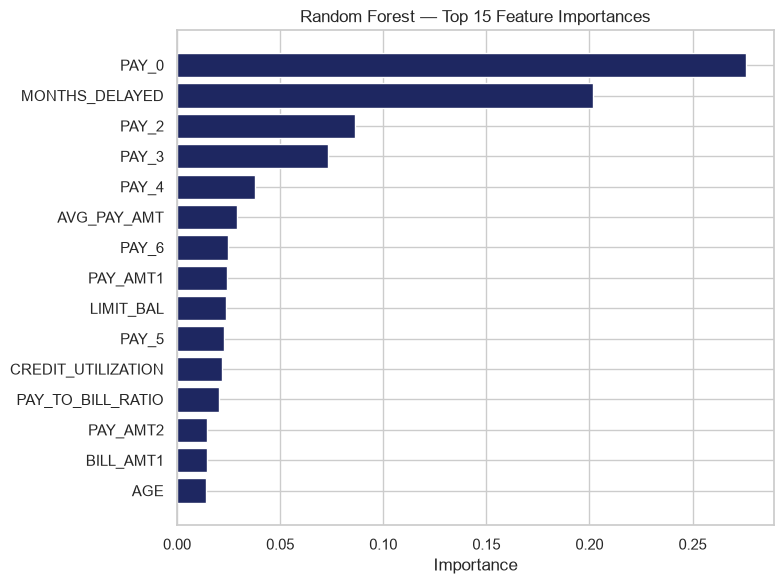

In [25]:
rf_model = fitted_models["RandomForest"].stages[-1]
importances = rf_model.featureImportances.toArray()

imp_series = pd.Series(importances, index=range(len(importances))).sort_values(ascending=False).head(15)
# Map the first N (numeric, non-OHE-expanded) slots back to their real names for readability
name_map = {i: n for i, n in enumerate(numeric_cols_final)}
labels = [name_map.get(i, f"onehot_slot_{i}") for i in imp_series.index]

plt.figure(figsize=(8,6))
plt.barh(range(len(imp_series)), imp_series.values[::-1], color=PALETTE[0])
plt.yticks(range(len(imp_series)), labels[::-1])
plt.title("Random Forest — Top 15 Feature Importances")
plt.xlabel("Importance")
plt.tight_layout(); plt.show()


In [26]:
spark.stop()